# Turkey Business Activity 

Run this end-to-end to analyze **your own** short YOLO sample from a public
Turkey camera AND compare it live to the **cloud dashboard's 24-hour history**
(pushed continuously by the admin's collector running on a GCP e2-micro).

What you get, top-to-bottom:

- Cells 1-6: pick a camera and verify the stream decodes.
- Cell 7: 1-minute local footfall time series.
- Cell 8: rolling z-score anomalies + peak-hour profile.
- Cells 9-10: dwell-time tracking (prolonged stops).
- Cells 11-14: appearance-based re-identification.
- Cell 15: "is it worth opening a business here?" — footfall + dwell + consistency.
- Cell 16: **the live cloud dashboard**, embedded inline, showing the admin's
  cumulative 24-hour view. Compare your local minute-of-samples against the day.
- Cells 17-18: rank multiple commercial sites; final summary.


### Network reality

The Istanbul streams (`kamerayayin.ibb.istanbul`, and the older
`livestream.ibb.gov.tr`) are public but reachable only from an **open
network** - your own machine, a VM, or a deployed app. Restricted
sandboxes (incl. the environment that generated this repo) block those
hosts via an allowlist. So **run this notebook locally**, where the
streams resolve. Heavy 1080p segments are downloaded head-only (first
~2.5 MB) so a single frame grab stays fast even on a slow link.

### How the grid chooses cameras: a country fallback ladder

The 24/7 cloud collector (on the VM) never watches a fixed set of cameras. It
runs a **`CountryDirector`** that always shows **4 cameras from one country**
and falls through a priority ladder when a country goes dark:

**Turkey - Thailand - Japan - USA**

Within each country there is a second ladder (the country's own camera list).
The rules:

- **Per-camera health.** A camera that misses 3 samples in a row rests for
  15 min; the grid backfills from deeper in the **same country's** bench. A
  `tvkur` (Konya) camera is a low-risk probe - one miss rests it.
- **Host circuit breaker.** When a whole host refuses access (HTTP 403/429 -
  what happens to Istanbul's IBB cameras from Google Cloud), *all* its cameras
  rest for 20 min and a single probe request decides when they return. This
  stops the collector from hammering a blocking CDN.
- **Country advance.** Only when the active country can field **no** live
  camera does the grid move to the next country. A single dead camera never
  moves the grid off a country - it just backfills.
- **Recovery before the report.** A few minutes before each daily report the
  collector re-probes higher-priority countries. Turkey is the subject, so the
  grid jumps back to it the moment its block lifts.

The report's fields (title, timezone for the hour-of-week baseline, the
day/night gate) follow whichever country - and camera - is live: a Bangkok
street and an Istanbul square cross into night at different UTC hours, and the
US bench alone spans Eastern, Central and Pacific time.

### Two runtimes: this notebook (strong) vs the VM collector (weak)

The exact same detection pipeline runs in two places, tuned differently:

| | **This notebook (local)** | **The VM collector (cloud)** |
|---|---|---|
| Purpose | Explore, calibrate, prove accuracy | 24/7 aggregation into Firestore |
| Model | **YOLO26-m** (2026 generation, medium) | **`yolov8n`** (nano) |
| Input size (`imgsz`) | 960 (recovers small/distant objects) | 512 (fits the free-tier CPU/RAM) |
| Hardware | your machine (can use a GPU) | GCP `e2-micro`, 2 shared vCPU, 1 GB |
| Cost | free, run on demand | must stay inside the Always-Free tier |

**Why weaker on the VM?** The `e2-micro` has ~1 GB RAM and two *shared* vCPUs.
A model like YOLO26-m at `imgsz=960` would blow the memory budget and make each
4-camera round take far longer than the 40 s sampling interval, so the loop
would fall behind. `yolov8n` at `imgsz=512` is the sweet spot that keeps the
collector real-time and inside the free tier - at the cost of missing some
small/distant objects, which is the accuracy this notebook exists to measure.

**How big is the gap?** On the same live frame, `yolov8n` found 2 people and 9
vehicles; **YOLO26-m found 12 people, 19 vehicles and 5 motorcycles nano missed
entirely.** So: this notebook is the accurate reference; the VM is the cheap,
always-on estimator. The calibration section quantifies the gap.

> There are two notebooks. **This one** (`turkey_business_activity.ipynb`, on
> GitHub) is the YOLO26-m reference. A local-only twin
> (`turkey_business_activity_yolov8n.ipynb`) is identical except it loads
> `yolov8n` - run it to see EXACTLY what the VM sees.

## 0. Setup

In [1]:
# Dependency check: verify every library the notebook needs is installed,
# install any that are missing, then print the installed versions.
# Safe to re-run - subsequent runs are just a version dump.
import importlib, subprocess, sys

# (import_name, pip_name). Pinned only where a min version matters.
REQUIREMENTS = [
    ('cv2',            'opencv-python-headless'),
    ('numpy',          'numpy'),
    ('pandas',         'pandas'),
    ('matplotlib',     'matplotlib'),
    ('PIL',            'Pillow'),
    ('ultralytics',    'ultralytics'),
    ('yt_dlp',         'yt-dlp'),
    ('firebase_admin', 'firebase-admin'),
    ('ipywidgets',     'ipywidgets>=8'),
    ('urllib3',        'urllib3'),
]

def _pip_install(spec: str) -> None:
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', '-q', spec],
        stdout=sys.stdout, stderr=sys.stderr,
    )

def _version(mod) -> str:
    return getattr(mod, '__version__', getattr(mod, 'VERSION', 'unknown'))

print(f'{"import":18} {"pip package":24} status')
print('-' * 66)
missing = []
for import_name, pip_spec in REQUIREMENTS:
    try:
        m = importlib.import_module(import_name)
        print(f'{import_name:18} {pip_spec:24} OK  v{_version(m)}')
    except ImportError:
        print(f'{import_name:18} {pip_spec:24} MISSING -> installing')
        missing.append((import_name, pip_spec))

for import_name, pip_spec in missing:
    _pip_install(pip_spec)
    importlib.invalidate_caches()
    m = importlib.import_module(import_name)
    print(f'  {import_name:16} installed  v{_version(m)}')

if missing:
    print()
    print('NOTE: some packages were just installed. If the next cell errors '
          'with ModuleNotFoundError, restart the kernel (Kernel -> Restart) '
          'and re-run from the top so Python picks up the new installs.')


import             pip package              status
------------------------------------------------------------------
cv2                opencv-python-headless   OK  v4.13.0
numpy              numpy                    OK  v2.3.5
pandas             pandas                   OK  v2.3.3
matplotlib         matplotlib               OK  v3.10.6
PIL                Pillow                   OK  v12.0.0
ultralytics        ultralytics              OK  v8.4.67
yt_dlp             yt-dlp                   OK  vunknown
firebase_admin     firebase-admin           OK  v7.4.0
ipywidgets         ipywidgets>=8            OK  v8.1.7
urllib3            urllib3                  OK  v2.5.0


In [2]:
import sys, time, datetime as dt
from collections import defaultdict
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Locate the src/ tree so the `app` package imports regardless of whether the
# notebook is run from the project root (default layout) or from inside src/.
_src_dir = Path.cwd() / 'src' if (Path.cwd() / 'src' / 'app').is_dir() else Path.cwd()
sys.path.append(str(_src_dir))
from app.detect_core import load_model, detect_and_count, grab_frame, resolve_youtube, resolve_stream, VEHICLE_NAMES
from app.cameras import CAMERAS, active_cameras, GRID_CAMERAS

# --- Model: the local STRONG reference detector ---------------------------
# This notebook is the accuracy reference - it runs a large, modern model to
# get the best counts possible. The 24/7 cloud VM runs the light yolov8n on a
# 1 GB e2-micro (see the "two runtimes" note near the top). YOLO26 is the 2026
# generation (highest mAP, NMS-free); the 'm' (medium) size is the accuracy
# sweet spot that still runs on a laptop CPU. First run downloads ~42 MB.
# The local-only twin notebook (turkey_business_activity_yolov8n.ipynb) sets
# this to 'yolov8n.pt' to mirror EXACTLY what the VM sees.
MODEL_WEIGHTS = 'yolo26m.pt'
DATA_DIR = _src_dir / 'data'; DATA_DIR.mkdir(parents=True, exist_ok=True)
model = load_model(str(_src_dir / MODEL_WEIGHTS))
print('model:', MODEL_WEIGHTS, '(VM runs yolov8n)')
print('cameras available:', list(active_cameras()))
print('dashboard grid (4 live cameras):', GRID_CAMERAS)

model: yolo26m.pt (VM runs yolov8n)
cameras available: ['konya_hukumet', 'taksim', 'taksim_yeni', 'beyazit_meydan', 'kapali_carsi', 'misir_carsisi', 'sultanahmet_1', 'sultanahmet_1_yeni', 'beyazit_meydan_yeni', 'eyup_sultan_yeni', 'buyuk_camlica_yeni', 'sarachane_yeni', 'sultanahmet_2_yeni', 'uskudar_yeni', 'salacak_yeni', 'kucukcekmece_yeni', 'ulus_parki_yeni', 'pierre_lotti_yeni', 'emirgan_yeni', 'kiz_kulesi_yeni', 'hidiv_kasri_yeni', 'dragos_yeni', 'kadikoy', 'eyup_sultan', 'uskudar', 'otogar_kavsagi', 'konya_kulturpark', 'konya_millet_caddesi', 'konya_ince_minareli', 'giresun_gazi', 'th_sukhumvit', 'th_chaweng_hooters', 'th_nanai_road', 'th_patong_sainamyen', 'th_petchaburi_traffic', 'th_green_mango', 'jp_shinsaibashi', 'jp_kabukicho_crossing', 'jp_kabukicho_shinjuku', 'jp_cross_space', 'jp_shibuya', 'jp_seibu_shinjuku', 'jp_tenjin', 'jp_kyoto_station', 'us_north_conway', 'us_boston_common', 'us_times_square', 'us_bellevue_2nd', 'us_church_st_burlington', 'us_houston_downtown', 'us

### Camera catalog + picker - pick 4 by number

The cell below prints the **full camera catalog** as one numbered list,
grouped by country, then asks you **four times** for a camera number - one
per grid slot. The four must be **distinct** and all from the **same
country** (the grid analyses one country at a time, exactly like the VM
collector: 4 cameras from one country, falling through to the next country
when one is blocked). After the fourth number it prints your selection and
the rest of the notebook analyses those four cameras.

> The pick is held for this kernel session, so **Run All** flows straight
> through after you enter the four numbers once. To choose a different grid:
> **Kernel > Restart Kernel** and run the picker again.

In [ ]:
# Camera catalog with LINKS - auto-generated from app/cameras.py, so it is
# always accurate and self-maintaining. Every camera, grouped by country,
# links to its source page (webcamera24 / IBB / tvkur).
from app.cameras import (CAMERAS as _CAT, COUNTRIES as _CO,
                         COUNTRY_ORDER as _OR, country_pool as _cp)
from IPython.display import display as _disp, HTML as _H

_rows = ['<div style="font-family:Arial,sans-serif;font-size:14px;max-height:'
         '360px;overflow:auto;border:1px solid #ddd;padding:10px 14px">',
         '<b>All available camera streams</b> (click a name to open its source):']
_n = 0
for _c in _OR:
    _m = _CO[_c]
    _rows.append(f'<h4 style="margin:10px 0 2px">{_m["flag"]} {_m["display"]}</h4>'
                 '<ol style="margin:0 0 6px 22px;padding:0">')
    for _cid in _cp(_c):
        _n += 1
        _cam = _CAT.get(_cid, {})
        _url = _cam.get("page") or _cam.get("url") or "#"
        _city = _cam.get("city", "")
        _where = f' <span style="color:#888">({_city})</span>' if _city else ''
        _rows.append(f'<li value="{_n}"><a href="{_url}" target="_blank" '
                     f'rel="noopener">{_cam.get("name", _cid)}</a>{_where}</li>')
    _rows.append('</ol>')
_rows.append(f'<div style="color:#888;margin-top:6px">{_n} cameras total. '
             'The picker below uses these same numbers.</div></div>')
_disp(_H(''.join(_rows)))

In [3]:
# CAMERA PICKER - one big catalog, pick 4 cameras by NUMBER.
# Prints every camera with a number, then asks you 4 times for a camera
# number. The 4 must be DISTINCT and all from the SAME country (the grid runs
# one country at a time, exactly like the VM collector). The pick is held for
# this kernel session; Kernel > Restart Kernel to choose a different grid.
from app.cameras import (CAMERAS as _CATALOG, COUNTRIES as _COUNTRIES,
                         COUNTRY_ORDER as _ORDER, country_pool as _country_pool)

MAX_CAMS = 4

# One numbered catalog across ALL countries, in the collector's priority
# order. _CAT_IDS[i] is the cam_id shown as number i+1.
_CAT_IDS = []
print("=" * 66)
print("CAMERA CATALOG  -  pick 4 cameras by number (all from ONE country)")
print("=" * 66)
for _c in _ORDER:
    _m = _COUNTRIES[_c]
    print(f'\n{_m["flag"]}  {_m["display"].upper()}')
    for _cid in _country_pool(_c):
        _CAT_IDS.append(_cid)
        _cam = _CATALOG.get(_cid, {})
        _city = _cam.get("city", "")
        _where = f'  ({_city})' if _city else ''
        print(f'  {len(_CAT_IDS):2d}.  {_cam.get("name", _cid)}{_where}')
_N = len(_CAT_IDS)
print("-" * 66)


def _country_of(cid):
    return _CATALOG.get(cid, {}).get("country")


# Keep a valid, already-applied pick across re-runs so Run All flows straight
# through after the one-time selection. A fresh kernel starts unapplied.
_prev = globals().get('SELECTED_CAMS')
_prev_country = globals().get('SELECTED_COUNTRY')
_KEEP = (bool(globals().get('SELECTED_CAMS_APPLIED'))
         and isinstance(_prev, list) and len(_prev) == MAX_CAMS
         and _prev_country in _COUNTRIES
         and all(c in _country_pool(_prev_country) for c in _prev))

if _KEEP:
    print(f'APPLIED (kept): {_prev_country} -> {_prev}')
    print('Selection held from earlier this session. '
          'Kernel > Restart Kernel to change it.')
else:
    try:
        _picks = []
        _country = None
        while len(_picks) < MAX_CAMS:
            _raw = input(f'Camera {len(_picks) + 1} of {MAX_CAMS}  '
                         f'(number 1-{_N}): ').strip()
            if not _raw.isdigit() or not (1 <= int(_raw) <= _N):
                print(f'  x  "{_raw}" is not a number between 1 and {_N}. '
                      'Try again.')
                continue
            _cid = _CAT_IDS[int(_raw) - 1]
            if _cid in _picks:
                print(f'  x  #{_raw} ({_CATALOG[_cid]["name"]}) already picked. '
                      'Choose another.')
                continue
            _cc = _country_of(_cid)
            if _country is None:
                _country = _cc
            elif _cc != _country:
                print(f'  x  #{_raw} is in {_cc}, but you started with '
                      f'{_country}. All 4 must be ONE country. Try again.')
                continue
            _picks.append(_cid)
            print(f'  ok  {len(_picks)}/{MAX_CAMS}: '
                  f'{_CATALOG[_cid]["name"]} ({_country})')
        SELECTED_CAMS = list(_picks)
        SELECTED_COUNTRY = _country
        SELECTED_CAMS_APPLIED = True
        print("=" * 66)
        print(f'APPLIED: {SELECTED_COUNTRY} -> {SELECTED_CAMS}')
        print('Run the cells below (or Run All).')
    except (EOFError, KeyboardInterrupt):
        SELECTED_CAMS_APPLIED = False
        print('\nPicker cancelled - nothing selected. Re-run this cell.')
    except Exception as _e:
        # Headless execution (nbconvert/papermill) has no stdin.
        if type(_e).__name__ == 'StdinNotImplementedError':
            SELECTED_CAMS_APPLIED = False
            print('This picker needs an interactive kernel (it calls '
                  'input()). Run it in Jupyter, not headless.')
        else:
            raise

CAMERA CATALOG  -  pick 4 cameras by number (all from ONE country)

TR  TURKEY
   1.  Taksim Meydani (live)  (Istanbul)
   2.  Sultanahmet (live)  (Istanbul)
   3.  Eyup Sultan (live)  (Istanbul)
   4.  Beyazit Meydani (live)  (Istanbul)
   5.  Konya - Hukumet Meydani / Sarraflar Yeralti Carsisi  (Konya)
   6.  Otogar Kavsagi  (Konya)
   7.  Konya - Kulturpark  (Konya)
   8.  Konya - Millet Caddesi / Hastane Kavsagi  (Konya)
   9.  Buyuk Camlica (live)  (Istanbul)
  10.  Konya - Ince Minareli Medrese (tram line)  (Konya)
  11.  Sarachane (live)  (Istanbul)
  12.  Sultanahmet 2 (live)  (Istanbul)
  13.  Uskudar (live)  (Istanbul)
  14.  Salacak (live)  (Istanbul)
  15.  Kucukcekmece (live)  (Istanbul)
  16.  Ulus Parki (live)  (Istanbul)
  17.  Pierre Lotti (live)  (Istanbul)
  18.  Emirgan (live)  (Istanbul)
  19.  Kiz Kulesi (live)  (Istanbul)
  20.  Hidiv Kasri (live)  (Istanbul)
  21.  Dragos (live)  (Istanbul)

TH  THAILAND
  22.  Sukhumvit Rd (Bangkok)  (Bangkok)
  23.  Chaweng Be

Camera 1 of 4  (number 1-43):  1


  ok  1/4: Taksim Meydani (live) (turkey)


Camera 2 of 4  (number 1-43):  2


  ok  2/4: Sultanahmet (live) (turkey)


Camera 3 of 4  (number 1-43):  3


  ok  3/4: Eyup Sultan (live) (turkey)


Camera 4 of 4  (number 1-43):  4


  ok  4/4: Beyazit Meydani (live) (turkey)
APPLIED: turkey -> ['taksim_yeni', 'sultanahmet_1_yeni', 'eyup_sultan_yeni', 'beyazit_meydan_yeni']
Run the cells below (or Run All).


### Picked cameras

The single checkpoint the rest of the notebook depends on. Before you Apply
in the picker above it stops politely (expected on a fresh run); after
Apply it records the final selection the whole run will use.

In [4]:
# PICKED CAMERAS - the checkpoint for everything below.
if not globals().get('SELECTED_CAMS_APPLIED'):
    class _ApplyFirst(Exception):
        def _render_traceback_(self):
            return [
                'PAUSED: no cameras selected yet (expected on a fresh run).',
                'In the picker cell above: enter your 4 camera numbers,',
                'then run this cell - or Run All.',
            ]
    raise _ApplyFirst()

from IPython.display import display, HTML
_ctry = globals().get('SELECTED_COUNTRY', 'turkey')
_rows = ''.join(f'<li><b>{c}</b> - {CAMERAS[c]["name"]}</li>'
                for c in SELECTED_CAMS)
display(HTML(
    '<div style="border:3px solid #16a34a;background:#f0fdf4;padding:14px 16px;">'
    f'<b style="font-size:16px;color:#166534;">APPLIED. COUNTRY = {_ctry} | '
    f'SELECTED_CAMS = {SELECTED_CAMS}</b>'
    f'<ul style="margin:8px 0 4px 20px;">{_rows}</ul>'
    f'<b>The rest of the notebook will analyse THESE {len(SELECTED_CAMS)} '
    f'cameras from {_ctry}.</b></div>'))

## 1. Pick a camera

The full catalog lives in `app/cameras.py`, organised into per-country pools
(`COUNTRIES` / `country_pool`). The cloud collector walks a **country ladder**
(Turkey -> Thailand -> Japan -> USA): it runs four DISTINCT cameras from ONE
country and falls through to the next country when the current one is blocked
or dark. The picker above mirrors that - you chose four cameras from a single
country, and `SELECTED_CAMS[0]` is the one this section inspects.

`resolve_stream(cam)` turns any catalog entry into an openable HLS URL
regardless of `kind`, and caches the result until its token expires:

- `hls` - used directly (kamerayayin / tvkur).
- `youtube` - resolved via yt-dlp using the `android` client (Thailand /
  Japan / USA street cameras are all YouTube-backed).
- `skyline` - the tokenized `hd-auth.skylinewebcams.com` playlist, scraped live.
- `webcamera24` - the embedded tvkur/YouTube player on the webcamera24 page.

Some hosts only resolve from an **open network** (IBB is geo-blocked outside
Turkey; skyline/webcamera24 rotate tokens), so run this on your own machine;
in a restricted sandbox those cameras fail while the YouTube-backed ones work.

In [5]:
if not globals().get('SELECTED_CAMS_APPLIED'):
    class _ApplyFirst(Exception):
        def _render_traceback_(self):
            return ['PAUSED: run the picker cell above and enter your 4 camera numbers first.']
    raise _ApplyFirst()
# Read the operator's first choice from the verify cell above so the
# rest of this notebook analyses whatever camera they actually picked
# (instead of a hard-coded default that ignored their choice).
CAM_ID = SELECTED_CAMS[0]
cam = CAMERAS[CAM_ID]
stream_url = resolve_stream(cam)   # handles hls / youtube / skyline / webcamera24
print(cam['name'], '->', stream_url)


Taksim Meydani (live) -> https://kamerayayin.ibb.istanbul/turistikcam/taksim.stream/playlist.m3u8


## 2. Single-frame check

Confirm the stream decodes and YOLO sees the crowd before collecting anything.

frame shape: (1080, 1920, 3)
counts: {'person': 2, 'bicycle': 0, 'car': 0, 'motorcycle': 0, 'bus': 0, 'train': 0, 'truck': 0, 'vehicles': 0}


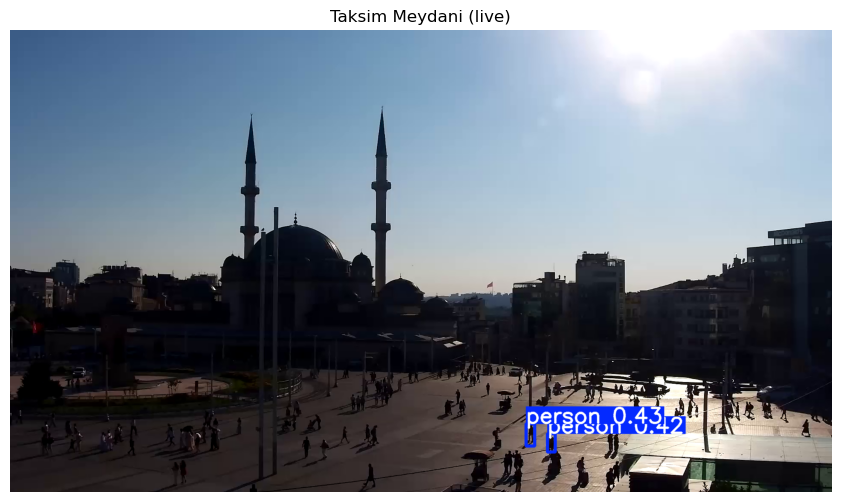

In [6]:
frame = grab_frame(stream_url)
if frame is None:
    print(f"WARN: {cam['name']} returned no frame (stream down or geo-blocked).")
    print('Pick a different camera: Kernel > Restart Kernel, then in the picker')
    print('choose another camera (or another country - Thailand/Japan/USA are')
    print('YouTube-backed and work from anywhere), enter its 4 numbers,')
    print('and Run All again.')
else:
    print('frame shape:', frame.shape)
    print('counts:', detect_and_count(model, frame))

    res = model.predict(frame, conf=0.35, classes=[0,1,2,3,5,7], verbose=False)[0]
    plt.figure(figsize=(11, 6))
    plt.imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)); plt.axis('off')
    plt.title(cam['name']); plt.show()

## 3. Footfall time series (sparse sampling)

For the **how much / when** question we don't need every frame - one sample every 15-30s is plenty and
is gentle on the server. This is the same logic the collector runs continuously.

In [7]:
def footfall_series(stream_url, cam_name, interval_s=20, duration_min=1.0):
    rows, t_end = [], time.time() + duration_min * 60
    while time.time() < t_end:
        ts = dt.datetime.now(dt.timezone.utc)
        f = grab_frame(stream_url)
        c = detect_and_count(model, f) if f is not None else {'person': np.nan, 'vehicles': np.nan}
        rows.append({'ts': ts, 'cam': cam_name, 'person': c.get('person'), 'vehicles': c.get('vehicles')})
        print(f"[{ts:%H:%M:%S}] person={c.get('person')} vehicles={c.get('vehicles')}")
        time.sleep(interval_s)
    return pd.DataFrame(rows)

# Short live-collection run. Raise duration_min for longer studies, or just leave the
# collector daemon (`python -m app.collector`) running for genuine 24/7 data.
df = footfall_series(stream_url, cam['name'], interval_s=10, duration_min=1.0)
df.to_csv(DATA_DIR / f'footfall_{CAM_ID}.csv', index=False)
df.head()

[15:23:43] person=2 vehicles=0
[15:23:56] person=2 vehicles=0
[15:24:09] person=4 vehicles=0
[15:24:22] person=2 vehicles=0
[15:24:35] person=0 vehicles=0


,ts,cam,person,vehicles
0,2026-07-17 15:23:43.454220+00:00,Taksim Meydani (live),2,0
1,2026-07-17 15:23:56.292454+00:00,Taksim Meydani (live),2,0
2,2026-07-17 15:24:09.682927+00:00,Taksim Meydani (live),4,0
3,2026-07-17 15:24:22.500004+00:00,Taksim Meydani (live),2,0
4,2026-07-17 15:24:35.475737+00:00,Taksim Meydani (live),0,0


## 4. Anomalies + peak-hour profile

**Anomaly = rolling z-score > 2.5** on the footfall series: a sudden surge (event/promotion/protest) or an
unusual drop (closure/weather). Peak-hour profile tells you *when* the commercial window is.

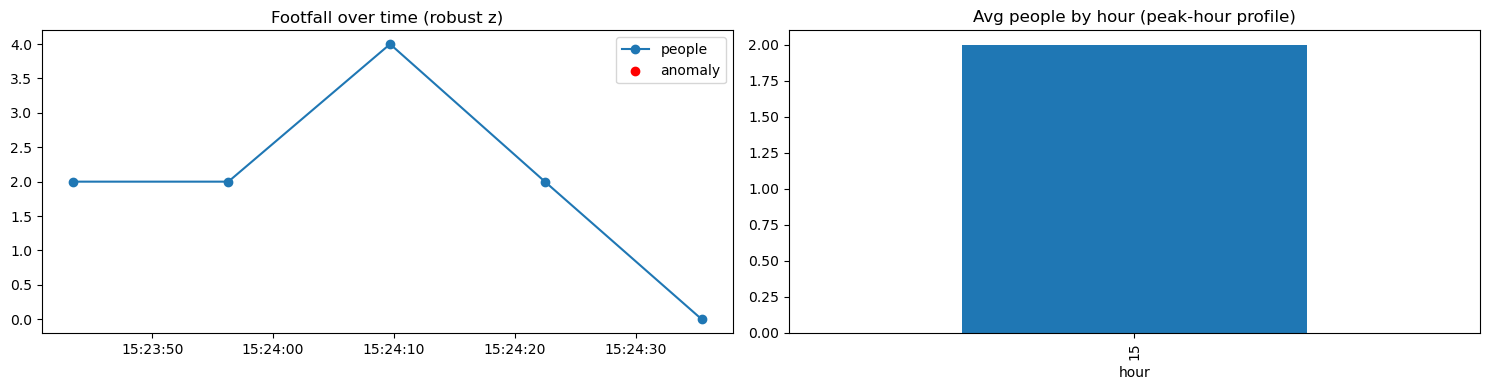

In [8]:
def flag_anomalies(s, window=12, z=3.5, min_delta=3):
    """Robust rolling z: median + MAD (x1.4826), the same statistic the cloud
    collector uses. Outliers already inside the window inflate a mean/std
    baseline and mask the next event; a median/MAD baseline barely moves."""
    med = s.rolling(window, min_periods=4).median()
    mad = (s - med).abs().rolling(window, min_periods=4).median() * 1.4826
    spread = mad.clip(lower=1.0)   # counts are integers; floor the spread
    robust_z = (s - med) / spread
    return (robust_z.abs() > z) & ((s - med).abs() >= min_delta)

df['ts'] = pd.to_datetime(df['ts'])
df['anomaly'] = flag_anomalies(df['person'])

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(df['ts'], df['person'], marker='o', label='people')
an = df[df['anomaly'] == True]
ax[0].scatter(an['ts'], an['person'], color='red', zorder=5, label='anomaly')
ax[0].set_title('Footfall over time (robust z)'); ax[0].legend()

df['hour'] = df['ts'].dt.hour
df.groupby('hour')['person'].mean().plot(kind='bar', ax=ax[1])
ax[1].set_title('Avg people by hour (peak-hour profile)')
plt.tight_layout(); plt.show()

## 5. Dwell-time / prolonged stops (tracking)

"How long does a person or vehicle stay in front of the camera?" needs **object tracking** (stable IDs
across frames), which only works on *consecutive* frames - so here we take a short **dense burst**
(a few fps for ~60s) instead of sparse sampling. Ultralytics `model.track()` (ByteTrack) gives each
object an id; we accumulate how many frames each id is seen and how little it moves.

- **Long dwell + low movement** = lingering: window-shopping / a queue / a parked vehicle.
- High share of *lingering* people is a strong **commercial-quality** signal (people stop, not just pass).

In [9]:
from app.detect_core import iter_frames, NAME_BY_ID

def dwell_analysis(stream_url, seconds=30, target_fps=3, conf=0.35):
    """Dense burst with tracking. Returns per-track dwell seconds + movement.

    iter_frames handles header-required hosts (tvkur, IBB, skylinewebcams) by
    downloading the latest segments with the right Referer/Origin and decoding
    locally, since cv2.VideoCapture(url) can't pass headers on Windows.
    """
    frames_seen = defaultdict(int)
    centroids = defaultdict(list)
    track_cls = {}
    n_frames = int(seconds * target_fps)
    for frame in iter_frames(stream_url, max_frames=n_frames):
        r = model.track(frame, persist=True, conf=conf, classes=[0,2,3,5,7],
                        tracker='bytetrack.yaml', verbose=False)[0]
        if r.boxes.id is not None:
            for box, tid, cl in zip(r.boxes.xywh.cpu().numpy(),
                                    r.boxes.id.int().cpu().tolist(),
                                    r.boxes.cls.int().cpu().tolist()):
                frames_seen[tid] += 1
                centroids[tid].append((float(box[0]), float(box[1])))
                track_cls[tid] = cl

    rows = []
    for tid, n in frames_seen.items():
        pts = np.array(centroids[tid])
        movement = float(np.linalg.norm(pts.max(0) - pts.min(0))) if len(pts) > 1 else 0.0
        rows.append({'track_id': tid,
                     'class': NAME_BY_ID.get(track_cls[tid], str(track_cls[tid])),
                     'dwell_s': round(n / target_fps, 1),
                     'movement_px': round(movement, 1)})
    return pd.DataFrame(rows).sort_values('dwell_s', ascending=False) if rows else pd.DataFrame(
        columns=['track_id','class','dwell_s','movement_px'])

dwell = dwell_analysis(stream_url, seconds=30, target_fps=3, conf=0.25)
dwell.head(15)

,track_id,class,dwell_s,movement_px
6,7,person,26.0,99.4
2,3,person,25.3,61.1
5,6,person,23.7,31.5
3,4,person,16.3,64.9
13,29,person,14.3,141.8
11,21,person,13.7,23.4
18,91,person,9.3,43.3
23,144,person,9.0,15.8
14,38,person,7.0,45.5
29,178,person,5.0,24.9


In [10]:
# Flag prolonged stationary objects: long dwell AND little movement.
PERSON_DWELL_S, VEHICLE_DWELL_S, MAX_MOVE_PX = 25, 40, 60
if not dwell.empty:
    is_person = dwell['class'] == 'person'
    stationary = dwell[((is_person & (dwell['dwell_s'] >= PERSON_DWELL_S)) |
                        (~is_person & (dwell['dwell_s'] >= VEHICLE_DWELL_S)))
                       & (dwell['movement_px'] <= MAX_MOVE_PX)]
    print(f"Prolonged stops detected: {len(stationary)}")
    display(stationary)
    linger_rate = (is_person & (dwell['dwell_s'] >= PERSON_DWELL_S)).sum() / max(1, is_person.sum())
    print(f"Linger rate (people who stayed >= {PERSON_DWELL_S}s): {linger_rate:.0%}")

Prolonged stops detected: 0


,track_id,class,dwell_s,movement_px


Linger rate (people who stayed >= 25s): 6%


## 5b. Re-identification - "have I seen this person before?"

The detection counts above tell you *how many* people are visible at any moment, but they
double-count anyone who lingers in front of the camera. To answer questions like *"how many
unique customers walked by today?"* or *"is that the same delivery van I saw yesterday?"*
we need **re-identification**: a persistent identity attached to each person/vehicle that
survives across frames, bursts and days.

The implementation is in `app/reid.py`:

1. For each YOLO detection, crop the bounding box.
2. Build a *masked* HSV color histogram (8x8x8 bins, V<30 pixels ignored - kills the
   sodium-yellow night cast on the Konya square) plus aspect ratio + normalized area.
3. L2-normalize -> 514-dim appearance vector.
4. Compare to every entity of the same class already in `data/reid.db` via cosine
   similarity. If the best match is >= `threshold` (default 0.92) we update its
   `sightings` and `last_seen`; otherwise we register a new entity.

This is a **demo-grade signature**. It works well in daylight (different clothing colors
give clearly different histograms). It produces false matches at night when the whole
scene is yellow-tinted - swap `embed_crop()` for an OSNet/torchreid forward pass for
production-grade re-ID; the SQLite registry around it stays the same.

In [11]:
if not globals().get('SELECTED_CAMS_APPLIED'):
    class _ApplyFirst(Exception):
        def _render_traceback_(self):
            return ['PAUSED: run the picker cell above and enter your 4 camera numbers first.']
    raise _ApplyFirst()
from app.detect_core import load_model, grab_frame, detect_with_boxes, annotate
from app.reid import ReidStore
import cv2, time
import matplotlib.pyplot as plt

REID_DB = str(_src_dir / 'data' / 'reid_notebook.db')
Path(REID_DB).parent.mkdir(parents=True, exist_ok=True)

# If we're re-running the notebook (the kernel is alive), the previous ReidStore is
# still holding a SQLite connection to REID_DB. Close it before we try to delete
# the file, otherwise Windows returns PermissionError [WinError 32].
try:
    reid.close()         # noqa: F821  (reid is defined by a prior run of this cell)
except NameError:
    pass

# Fresh registry for the demo so re-runs are reproducible. If something else
# still holds the file (orphan kernel, antivirus scan), we keep the existing
# rows instead of crashing - re-identification just continues with what's there.
try:
    Path(REID_DB).unlink(missing_ok=True)
    print('reid_notebook.db cleared - fresh demo registry')
except PermissionError:
    print('reid_notebook.db is locked by another process - keeping existing rows. '
          'New entities will be merged into the existing registry; this is fine '
          'for the demo, just not a clean-room run.')

reid = ReidStore(REID_DB, threshold=0.92)

# Use the model we already loaded above; lower conf so we catch the small/distant
# people the Konya wide-angle camera shows.
# CAM_ID inherits from the verify cell (SELECTED_CAMS[0]) so re-ID runs on
# the same camera as the earlier sections, not a hard-coded default.
CAM_ID = SELECTED_CAMS[0]
cam = CAMERAS[CAM_ID]
stream_url = cam['url']
print('feeding re-ID from', cam['name'])

reid_notebook.db cleared - fresh demo registry
feeding re-ID from Taksim Meydani (live)


In [12]:
# Sample N frames every `interval_s` seconds, run YOLO on each, push every detection
# through the re-ID registry. Short loop here so the notebook completes; the collector
# daemon does the real long-running version.
N_SAMPLES, INTERVAL_S, CONF = 8, 5, 0.25

rows = []
for i in range(N_SAMPLES):
    f = grab_frame(stream_url)
    if f is None:
        print(f'[{i:02d}] miss'); time.sleep(INTERVAL_S); continue
    counts, boxes = detect_with_boxes(model, f, conf=CONF)
    results = reid.update_from_frame(CAM_ID, f, boxes)
    new = sum(r.is_new for r in results)
    seen_again = len(results) - new
    rows.append({'sample': i, 'person': counts['person'], 'vehicles': counts['vehicles'],
                 'detections': len(boxes), 'new_ids': new, 'seen_again': seen_again})
    print(f'[{i:02d}] person={counts["person"]} vehicles={counts["vehicles"]} '
          f'-> new={new} seen_again={seen_again}')
    time.sleep(INTERVAL_S)

reid_df = pd.DataFrame(rows)
reid_df

[00] person=10 vehicles=1 -> new=11 seen_again=0
[01] person=1 vehicles=0 -> new=0 seen_again=1
[02] person=11 vehicles=2 -> new=9 seen_again=4
[03] person=2 vehicles=0 -> new=2 seen_again=0
[04] person=7 vehicles=0 -> new=3 seen_again=4
[05] person=12 vehicles=0 -> new=8 seen_again=4
[06] person=10 vehicles=0 -> new=6 seen_again=4
[07] person=7 vehicles=1 -> new=7 seen_again=1


,sample,person,vehicles,detections,new_ids,seen_again
0,0,10,1,11,11,0
1,1,1,0,1,0,1
2,2,11,2,13,9,4
3,3,2,0,2,2,0
4,4,7,0,7,3,4
5,5,12,0,12,8,4
6,6,10,0,10,6,4
7,7,7,1,8,7,1


In [13]:
# Roll-up: how many unique entities did we see? how many came back >=3 times?
stats = reid.stats(CAM_ID)
print('Total unique entities (this camera):', stats['total_unique'])
print('Total sightings:', stats['total_sightings'])
for cls, s in stats['per_class'].items():
    print(f"  {cls:10s}  unique={s['unique']}  sightings={s['total_sightings']}  "
          f"regulars(>=3)={s['regulars']}")

print('\nTop returning entities:')
for r in reid.top_regulars(CAM_ID, n=10):
    print(f"  #{r['entity_id']:4d}  {r['cls']:8s}  sightings={r['sightings']}  "
          f"first={r['first_seen']}  last={r['last_seen']}")

Total unique entities (this camera): 46
Total sightings: 64
  bus         unique=1  sightings=1  regulars(>=3)=0
  car         unique=3  sightings=3  regulars(>=3)=0
  person      unique=42  sightings=60  regulars(>=3)=5

Top returning entities:
  #   2  person    sightings=4  first=2026-07-17T15:26:26Z  last=2026-07-17T15:27:22Z
  #   7  person    sightings=3  first=2026-07-17T15:26:26Z  last=2026-07-17T15:27:14Z
  #  11  person    sightings=3  first=2026-07-17T15:26:26Z  last=2026-07-17T15:26:42Z
  #  13  person    sightings=3  first=2026-07-17T15:26:42Z  last=2026-07-17T15:27:05Z
  #  15  person    sightings=3  first=2026-07-17T15:26:42Z  last=2026-07-17T15:27:05Z
  #   5  person    sightings=2  first=2026-07-17T15:26:26Z  last=2026-07-17T15:26:42Z
  #   9  person    sightings=2  first=2026-07-17T15:26:26Z  last=2026-07-17T15:26:42Z
  #  10  person    sightings=2  first=2026-07-17T15:26:26Z  last=2026-07-17T15:26:42Z
  #  21  person    sightings=2  first=2026-07-17T15:26:50Z  last=2

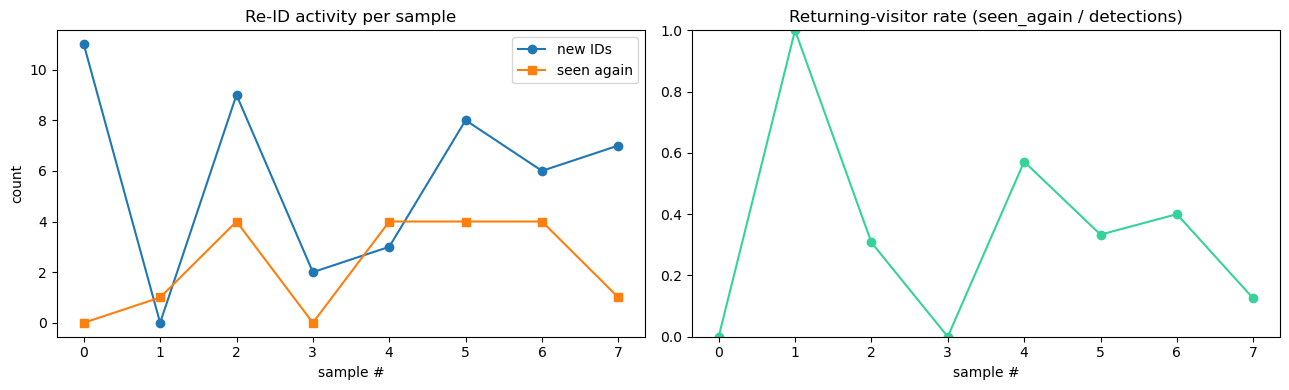

In [14]:
# Visual: returning-visitor curve - what fraction of detections are 'seen again' over time?
if len(reid_df) >= 3:
    reid_df = reid_df.copy()
    reid_df['returning_rate'] = (reid_df['seen_again'] /
                                 reid_df['detections'].replace(0, np.nan))
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(reid_df['sample'], reid_df['new_ids'], marker='o', label='new IDs')
    ax[0].plot(reid_df['sample'], reid_df['seen_again'], marker='s', label='seen again')
    ax[0].set_title('Re-ID activity per sample')
    ax[0].set_xlabel('sample #'); ax[0].set_ylabel('count'); ax[0].legend()

    ax[1].plot(reid_df['sample'], reid_df['returning_rate'].fillna(0), marker='o',
               color='#36d399')
    ax[1].set_title('Returning-visitor rate (seen_again / detections)')
    ax[1].set_xlabel('sample #'); ax[1].set_ylim(0, 1)
    plt.tight_layout(); plt.show()
else:
    print('Not enough samples for the returning-visitor plot.')

IMPORTANT - re-ID quality depends on the scene.
#
At Konya Hukumet Meydani at night the whole scene is uniform sodium yellow.
Color-histogram re-ID will over-merge IDs there. To validate the *concept*, point
the camera at the daylight Grand Bazaar / Spice Bazaar (different clothing colors)
or set `threshold=0.97` to be very conservative about matches.
#
Production path:
  pip install torchreid
  from torchreid.utils import FeatureExtractor
  extractor = FeatureExtractor(model_name='osnet_ain_x1_0', model_path='', device='cpu')
  def embed_crop(crop, cls): return extractor([crop])[0].cpu().numpy()
Then keep the rest of app/reid.py exactly as-is. The 2,048-dim OSNet embedding
survives lighting changes, pose changes, and partial occlusion much better than
a color histogram.

## 6. "Is it worth opening a business here?" - a simple score

Combine three signals into one 0-100 score. Tune the weights to your business type (a cafe wants high
*linger*; a kiosk wants high *throughput*).

- **Volume** - median footfall (raw demand).
- **Linger** - share of people who stop (engagement / conversion potential).
- **Consistency** - low coefficient of variation (steady traffic beats spiky).

In [15]:
def business_score(footfall_df, dwell_df, w=(0.5, 0.3, 0.2)):
    people = footfall_df['person'].dropna()
    volume = float(people.median()) if len(people) else 0.0
    cv = float(people.std() / people.mean()) if people.mean() else 1.0
    consistency = max(0.0, 1 - cv)
    is_p = dwell_df['class'] == 'person'
    linger = float((is_p & (dwell_df['dwell_s'] >= 25)).sum() / max(1, is_p.sum())) if len(dwell_df) else 0.0
    vol_norm = min(1.0, volume / 40.0)  # ~40 people/frame treated as 'very busy'; tune per camera FOV
    score = 100 * (w[0]*vol_norm + w[1]*linger + w[2]*consistency)
    return {'volume_median': round(volume,1), 'linger_rate': round(linger,2),
            'consistency': round(consistency,2), 'score_0_100': round(score,1)}

print(cam['name'])
business_score(df, dwell)

Taksim Meydani (live)


{'volume_median': 2.0,
 'linger_rate': 0.06,
 'consistency': 0.29,
 'score_0_100': 10.2}

## 7. Compare with the live cloud dashboard

The rest of this notebook was your **local** analysis — a minute of sampling on
one camera. The cloud collector has been running non-stop on a GCP VM,
accumulating 4 cameras × 24 hours into Firestore, and the HTML dashboard below
subscribes to that. Comparing the two answers real questions:

- Is the moment I sampled representative of the whole day? (my minute vs the 24h chart)
- Am I hitting a peak, a valley, or the average?
- Did any anomaly fire in the last 24 hours that I missed by sampling now?

Nothing here writes to Firestore — it's a plain HTML page that reads from it.


In [16]:
# Serve web/ locally on http://localhost:8000 and embed the live dashboard.
# The dashboard reads directly from Firestore (public-read) — no credentials
# needed. The tvkur HLS proxy lets the Konya tiles autoplay.
import sys, threading, http.server, webbrowser
from app.dashboard_server import DashboardHandler, WEB_DIR, port_is_free

DASHBOARD_PORT = 8000
_main = sys.modules['__main__']

if getattr(_main, '_dash_server', None) is None:
    if not port_is_free(DASHBOARD_PORT):
        print(f'Port {DASHBOARD_PORT} already in use — assuming a dashboard is up. '
              f'Open http://localhost:{DASHBOARD_PORT}/')
        _main._dash_server = 'external'
    else:
        factory = lambda *a, **k: DashboardHandler(*a, directory=str(WEB_DIR), **k)
        http.server.ThreadingHTTPServer.allow_reuse_address = True
        http.server.ThreadingHTTPServer.daemon_threads      = True
        srv = http.server.ThreadingHTTPServer(('', DASHBOARD_PORT), factory)
        threading.Thread(target=srv.serve_forever, daemon=True).start()
        _main._dash_server = srv
        print(f'Dashboard server started at http://localhost:{DASHBOARD_PORT}/')

dash_url = f'http://localhost:{DASHBOARD_PORT}/'
if not getattr(_main, '_dash_browser_opened', False):
    try:    webbrowser.open(dash_url, new=2)
    except: pass
    _main._dash_browser_opened = True

from IPython.display import display, HTML, IFrame
display(HTML(f'<p><b>Live dashboard (cloud collector, 24h TTL):</b> '
             f'<a href="{dash_url}" target="_blank">{dash_url}</a></p>'))
display(IFrame(dash_url, width='100%', height=640))


Dashboard server started at http://localhost:8000/


  "GET / HTTP/1.1" 200 -
  "GET /firebase-config.js?v=40 HTTP/1.1" 200 -
  "GET /cameras.js?v=40 HTTP/1.1" 200 -
  "GET /app.js?v=40 HTTP/1.1" 200 -
  "GET /api/review-stats HTTP/1.1" 200 -
  "GET /api/boost-status HTTP/1.1" 200 -
  "GET /api/model-metrics HTTP/1.1" 200 -
  "GET /api/review-frames-stats HTTP/1.1" 200 -
  "GET /tvkur/c77i84vbb2nj4i0fr80g/master.m3u8 HTTP/1.1" 502 -
  "GET /tvkur/c77i91vbb2nj4i0fr81g/master.m3u8 HTTP/1.1" 502 -
  "GET /tvkur/c77i6hb84cnrb6mlji3g/master.m3u8 HTTP/1.1" 502 -
  "GET /api/anomaly-crops-stats HTTP/1.1" 200 -
  "GET /tvkur/c77i9cfbb2nj4i0fr82g/master.m3u8 HTTP/1.1" 502 -
  "GET /tvkur/c77i84vbb2nj4i0fr80g/master.m3u8 HTTP/1.1" 502 -
  "GET /tvkur/c77i91vbb2nj4i0fr81g/master.m3u8 HTTP/1.1" 502 -
  "GET /api/live-samples-stats HTTP/1.1" 200 -
  "GET /api/review-frames-list HTTP/1.1" 200 -
  "GET /api/review-frame HTTP/1.1" 200 -
  "GET /snapshots/review_frames/konya_hukumet/1783763198890849.jpg HTTP/1.1" 200 -
  "GET /tvkur/c77i6hb84cnrb6mlji3g/

## 8. Compare multiple commercial sites

Loop the footfall sampler over several cameras to rank locations by activity - the input to a
site-selection decision.

In [17]:
if not globals().get('SELECTED_CAMS_APPLIED'):
    class _ApplyFirst(Exception):
        def _render_traceback_(self):
            return ['PAUSED: run the picker cell above and enter your 4 camera numbers first.']
    raise _ApplyFirst()
# Rank the cameras YOU picked in verify7cams above (SELECTED_CAMS) by
# activity. This is a LOCAL analysis - it uses your dynamic pick, not
# the fixed VM grid. Cameras that can't resolve or return no frames are
# skipped, so if some picks are down you still get a partial ranking.
summary = []
for cid in SELECTED_CAMS:
    c = CAMERAS.get(cid)
    if not c or not c.get('url'):
        print(f'{cid}: skipped (not in catalog or no url)')
        continue
    try:
        url = resolve_stream(c)
    except Exception as e:
        print(f'{cid}: resolve failed ({e})')
        continue
    # one quick decode check before spending 30s on this camera
    if grab_frame(url) is None:
        print(f'{cid}: no frame from stream (geo-blocked / down). Skipping.')
        continue
    sdf = footfall_series(url, c['name'], interval_s=10, duration_min=0.5)
    summary.append({'site': c['name'],
                    'median_people': sdf['person'].median(),
                    'max_people': sdf['person'].max()})

if summary:
    pd.DataFrame(summary).sort_values('median_people', ascending=False)
else:
    print('No camera in SELECTED_CAMS produced usable frames - nothing to rank.')


[15:27:32] person=7 vehicles=0
[15:27:46] person=1 vehicles=0
[15:27:58] person=4 vehicles=3
sultanahmet_1_yeni: no frame from stream (geo-blocked / down). Skipping.
eyup_sultan_yeni: no frame from stream (geo-blocked / down). Skipping.
beyazit_meydan_yeni: no frame from stream (geo-blocked / down). Skipping.


## 9. Live summary - what did we find?

Pulls everything the notebook saw on this run into a single block: the anomalies
flagged across every sampled camera, the re-ID totals, and a tiny visualisation
plotting all anomalies on the same timeline. Re-running the notebook regenerates
this from scratch - no stale timestamps from someone else's session leak through.

Notebook run finished at 2026-07-17 15:28:14 UTC
Live camera for this run: Taksim Meydani (live)

Anomalies flagged: 0
(Too few samples for the z-score window to trip, or the scene was steady.)

------------------------------------------------------------------------------
Re-identification - Taksim Meydani (live)
  total unique entities   : 46
  total sightings         : 64
    bus         unique=1  sightings=1  regulars(>=3)=0
    car         unique=3  sightings=3  regulars(>=3)=0
    person      unique=42  sightings=60  regulars(>=3)=5
  top returning:
    #   2  person    sightings=4  last_seen=2026-07-17T15:27:22Z
    #   7  person    sightings=3  last_seen=2026-07-17T15:27:14Z
    #  11  person    sightings=3  last_seen=2026-07-17T15:26:42Z
    #  13  person    sightings=3  last_seen=2026-07-17T15:27:05Z
    #  15  person    sightings=3  last_seen=2026-07-17T15:27:05Z


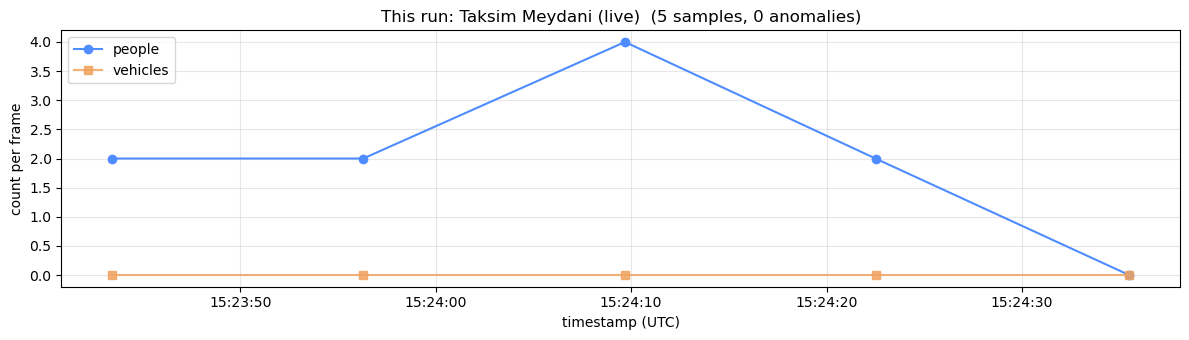


For the persistent shared HTML dashboard (Firestore-backed):
  collector  : run the cell in Section 7 of this notebook,
               or `python -m app.collector --interval 20 --only konya_hukumet,otogar_kavsagi,konya_kulturpark,konya_millet_caddesi`
  dashboard  : python serve.py        (from the project root)
  open       : http://localhost:8000  (opens automatically)


In [18]:
try:
    import pandas as pd
    import matplotlib.pyplot as plt
    from datetime import datetime, timezone

    print(f"Notebook run finished at {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S')} UTC")
    print(f"Live camera for this run: {cam['name']}")
    print("=" * 78)

    # ---- aggregate anomalies into one DataFrame ----
    anom_frames = []
    if "df" in dir() and isinstance(df, pd.DataFrame) and not df.empty and "anomaly" in df.columns:
        a = df[df["anomaly"] == True].copy()
        if not a.empty:
            a["cam"] = cam["name"]
            anom_frames.append(a[["ts", "cam", "person", "vehicles"]])
    anom = pd.concat(anom_frames, ignore_index=True) if anom_frames else \
           pd.DataFrame(columns=["ts", "cam", "person", "vehicles"])

    if len(anom):
        print(f"\nAnomalies flagged (rolling z > 2.5): {len(anom)}")
        print(anom.to_string(index=False))
    else:
        print("\nAnomalies flagged: 0")
        print("(Too few samples for the z-score window to trip, or the scene was steady.)")

    # ---- re-ID rollup ----
    if "reid" in dir():
        stats = reid.stats(CAM_ID)
        print("\n" + "-" * 78)
        print(f"Re-identification - {cam['name']}")
        print(f"  total unique entities   : {stats['total_unique']}")
        print(f"  total sightings         : {stats['total_sightings']}")
        for cls, s in stats["per_class"].items():
            print(f"    {cls:10s}  unique={s['unique']}  "
                  f"sightings={s['total_sightings']}  "
                  f"regulars(>=3)={s['regulars']}")
        regulars = reid.top_regulars(CAM_ID, n=5)
        if regulars:
            print("  top returning:")
            for r in regulars:
                print(f"    #{r['entity_id']:>4}  {r['cls']:8s}  "
                      f"sightings={r['sightings']}  last_seen={r['last_seen']}")

    # ---- always-on visual: footfall over this run + anomalies overlaid ----
    # Build the plot only when we have data; do NOT call ax.legend() on an empty
    # axes (that produces the "No artists with labels found" warning).
    if "df" in dir() and isinstance(df, pd.DataFrame) and not df.empty:
        ts = pd.to_datetime(df["ts"])
        fig, ax = plt.subplots(figsize=(12, 3.5))
        ax.plot(ts, df["person"],   marker="o", color="#4f8cff", label="people")
        ax.plot(ts, df["vehicles"], marker="s", color="#f0a35e", label="vehicles", alpha=0.85)
        if len(anom):
            ax.scatter(pd.to_datetime(anom["ts"]), anom["person"],
                       s=160, color="#ef4444", marker="X", zorder=5, label="anomaly")
        ax.set_title(f"This run: {cam['name']}  ({len(df)} samples, {len(anom)} anomalies)")
        ax.set_ylabel("count per frame"); ax.set_xlabel("timestamp (UTC)")
        ax.legend(loc="upper left"); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

    print("\n" + "=" * 78)
    print("For the persistent shared HTML dashboard (Firestore-backed):")
    print("  collector  : run the cell in Section 7 of this notebook,")
    print("               or `python -m app.collector --interval 20 --only "
          "konya_hukumet,otogar_kavsagi,konya_kulturpark,konya_millet_caddesi`")
    print("  dashboard  : python serve.py        (from the project root)")
    print("  open       : http://localhost:8000  (opens automatically)")

except Exception as e:
    print(f"summary cell stopped early: {type(e).__name__}: {e}")


## 10. Accuracy calibration - how good are the counts, really?

The dashboard is only as trustworthy as YOLO is on THESE cameras. This section
measures it: capture frames from the 4 live grid cameras, run the detector at
two input sizes (640 = old default, 960 = the collector's current default),
then count people/vehicles yourself and get MAE + bias per camera and per size.

Workflow (all local, ~10 minutes of counting):
1. **10a** captures frames + predictions into `data/calibration/`;
2. **10b** shows each frame - you type the true `people,vehicles`;
3. **10c** prints the accuracy table and a conf/imgsz recommendation.

Feed the result back into the pipeline: the winning `imgsz` goes to the
collector's `--imgsz`, and a camera with a systematic bias gets a `"conf"`
override in `app/cameras.py` (bias < 0 -> lower conf, bias > 0 -> raise it).

In [19]:
if not globals().get('SELECTED_CAMS_APPLIED'):
    class _ApplyFirst(Exception):
        def _render_traceback_(self):
            return ['PAUSED: run the picker cell above and enter your 4 camera numbers first.']
    raise _ApplyFirst()
# --- 10a. Capture calibration frames + predictions (run once, ~1-2 min) ---
import json as _json
from app.detect_core import grab_burst, detect_with_boxes, annotate

CALIB_DIR = DATA_DIR / 'calibration'; CALIB_DIR.mkdir(parents=True, exist_ok=True)
FRAMES_PER_CAM = 6          # 4 cams x 6 frames = 24 to label (aim for 20-30)
IMG_SIZES = (640, 960)      # old default vs the collector's current default
CALIB_CONF = 0.30           # keep in sync with the collector's --conf

samples = []
for cam_id in (SELECTED_CAMS if globals().get('SELECTED_CAMS')
               else GRID_CAMERAS):
    cam = CAMERAS[cam_id]
    try:
        url = resolve_stream(cam)
    except Exception as e:
        print(f'{cam_id}: resolve failed ({e}) - skipping'); continue
    got = 0
    for k in range(FRAMES_PER_CAM):
        frames = grab_burst(url, n=1)
        if not frames:
            print(f'{cam_id}: frame {k} MISS'); continue
        frame = frames[0]
        stem = f'{cam_id}_{k:02d}'
        cv2.imwrite(str(CALIB_DIR / f'{stem}.jpg'), frame)
        entry = {'stem': stem, 'cam_id': cam_id}
        for size in IMG_SIZES:
            counts, _ = detect_with_boxes(model, frame, conf=CALIB_CONF, imgsz=size)
            entry[f'person_{size}']   = counts['person']
            entry[f'vehicles_{size}'] = counts['vehicles']
        cv2.imwrite(str(CALIB_DIR / f'{stem}_annotated.jpg'),
                    annotate(model, frame, conf=CALIB_CONF, imgsz=max(IMG_SIZES)))
        samples.append(entry); got += 1
        time.sleep(2)   # let the live stream move on a little between captures
    print(f'{cam_id}: captured {got} frames')

(CALIB_DIR / 'predictions.json').write_text(_json.dumps(samples, indent=2))
print(f'{len(samples)} frames -> {CALIB_DIR}')

taksim_yeni: captured 6 frames
sultanahmet_1_yeni: frame 0 MISS
sultanahmet_1_yeni: frame 1 MISS
sultanahmet_1_yeni: frame 2 MISS
sultanahmet_1_yeni: frame 3 MISS
sultanahmet_1_yeni: frame 4 MISS
sultanahmet_1_yeni: frame 5 MISS
sultanahmet_1_yeni: captured 0 frames
eyup_sultan_yeni: frame 0 MISS
eyup_sultan_yeni: frame 1 MISS
eyup_sultan_yeni: frame 2 MISS
eyup_sultan_yeni: frame 3 MISS
eyup_sultan_yeni: frame 4 MISS
eyup_sultan_yeni: frame 5 MISS
eyup_sultan_yeni: captured 0 frames
beyazit_meydan_yeni: frame 0 MISS
beyazit_meydan_yeni: frame 1 MISS
beyazit_meydan_yeni: frame 2 MISS
beyazit_meydan_yeni: frame 3 MISS
beyazit_meydan_yeni: frame 4 MISS
beyazit_meydan_yeni: frame 5 MISS
beyazit_meydan_yeni: captured 0 frames
6 frames -> C:\Users\OR\Downloads\לימודים\Data Science\Project\Turkey Business Activity Streamlit Real-time YOLOv8 of crowd detection\src\data\calibration


In [20]:
# INTERACTIVE cell - it asks YOU to type counts, so it must never run
# under Run All (it would stall the whole run waiting for keyboard
# input). Set RUN_LABELING = True and re-run this cell when you are
# ready to label; leave it False for hands-off runs.
RUN_LABELING = globals().get('RUN_LABELING', False)
if not RUN_LABELING:
    print('Labeling skipped (RUN_LABELING is False).')
    print('When you want to label: set RUN_LABELING = True in this cell')
    print('and run it again - it will show each frame and ask for the')
    print('true people,vehicles counts.')
else:
    # --- 10b. Label: look at each frame, type the true counts ---
    # The annotated image shows what the model saw at imgsz=960. Count what YOU
    # see: people, then vehicles (cars+buses+trucks+motorbikes+bicycles), and type
    # `people,vehicles` (e.g. `7,3`). Enter = skip frame, q = stop early.
    import json as _json

    samples = _json.loads((CALIB_DIR / 'predictions.json').read_text())
    labeled = []
    for s in samples:
        img = cv2.cvtColor(cv2.imread(str(CALIB_DIR / f"{s['stem']}_annotated.jpg")),
                           cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(12, 7)); plt.imshow(img); plt.axis('off')
        plt.title(f"{s['stem']}  |  model@960: person={s['person_960']} "
                  f"vehicles={s['vehicles_960']}")
        plt.show()
        raw = input(f"{s['stem']} true 'people,vehicles' (Enter=skip, q=stop): ").strip()
        if raw.lower() == 'q':
            break
        if not raw:
            continue
        try:
            p_true, v_true = (int(x) for x in raw.replace(' ', '').split(','))
        except ValueError:
            print('  could not parse - skipped'); continue
        labeled.append({**s, 'person_true': p_true, 'vehicles_true': v_true})

    (CALIB_DIR / 'labeled.json').write_text(_json.dumps(labeled, indent=2))
    print(f'labeled {len(labeled)} frames -> {CALIB_DIR / "labeled.json"}')

Labeling skipped (RUN_LABELING is False).
When you want to label: set RUN_LABELING = True in this cell
and run it again - it will show each frame and ask for the
true people,vehicles counts.


In [21]:
# --- 10c. Accuracy report: MAE + bias per input size and per camera ---
import json as _json

rows = _json.loads((CALIB_DIR / 'labeled.json').read_text())
if not rows:
    class _LabelFirst(Exception):
        def _render_traceback_(self):
            return ['PAUSED: no labeled frames yet - set RUN_LABELING = True '
                    'in 10b, label a few frames, then run this cell again.']
    raise _LabelFirst()
cal = pd.DataFrame(rows)

overall = []
for size in IMG_SIZES:
    for metric in ('person', 'vehicles'):
        err = cal[f'{metric}_{size}'] - cal[f'{metric}_true']
        overall.append({'imgsz': size, 'metric': metric,
                        'MAE': round(err.abs().mean(), 2),
                        'bias': round(err.mean(), 2),   # negative = undercount
                        'n': len(cal)})
print('=== overall (all cameras) ===')
print(pd.DataFrame(overall).to_string(index=False))

best = max(IMG_SIZES)
per_cam = []
for cam_id, g in cal.groupby('cam_id'):
    for metric in ('person', 'vehicles'):
        err = g[f'{metric}_{best}'] - g[f'{metric}_true']
        per_cam.append({'cam': cam_id, 'metric': metric,
                        'MAE': round(err.abs().mean(), 2),
                        'bias': round(err.mean(), 2), 'n': len(g)})
print(f'=== per camera @ imgsz={best} ===')
print(pd.DataFrame(per_cam).to_string(index=False))

print("""
How to read this:
- bias < 0 -> systematic undercount: lower that camera's conf (add e.g.
  "conf": 0.25 to its entry in app/cameras.py). bias > 0 -> overcount: raise it.
- If MAE@960 < MAE@640 (typical for these wide shots), keep the collector's
  default --imgsz 960; otherwise fall back to 640.
- Re-run this section after any camera swap or weights change.""")

_LabelFirst: 